In [1]:
import ast
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [3]:
sns.set_context("paper", font_scale=1.25)
sns.set_palette("Set2")

In [4]:
dimension_map = {
    "Ackley": 30,
    # "Rastrigin": 50,
    # "Schwefel": 500,
    # "Sphere": 500,
    # "Rosenbrock": 100,
    # "Cigar": 50,
}

In [5]:
df = pd.read_csv("../data/experiments_results_final_2.csv")
df = pd.read_csv("../data/experiments_results.csv")
df["fitness_history"] = df["fitness_history"].apply(ast.literal_eval)
df.head()

,dimension,benchmark,algorithm,best_fitness,best_position,fitness_history,execution_time
0,30,Ackley,PSO,2.536509,"[-0.0080148369361214, 0.22553264230240355, 0.1...","[20.01530186955264, 19.42523213290174, 19.4252...",0.047808
1,30,Ackley,PSO,15.508285,"[1.9257667895251016, -1.985620895558032, 3.044...","[20.373591963934185, 19.875157847209614, 19.87...",0.061152
2,30,Ackley,PSO,3.178070,"[-0.11078695920364826, 0.18388435091947575, 0....","[19.642201347509147, 19.642201347509147, 19.64...",0.037593
3,30,Ackley,PSO,1.904173,"[-0.06430462182726973, 0.055806214469132656, 0...","[19.232527256180873, 19.232527256180873, 19.23...",0.037593
4,30,Ackley,PSO,3.053164,"[0.07877512690719579, -0.5798398154733629, -0....","[19.430836859566217, 19.430836859566217, 19.35...",0.039442


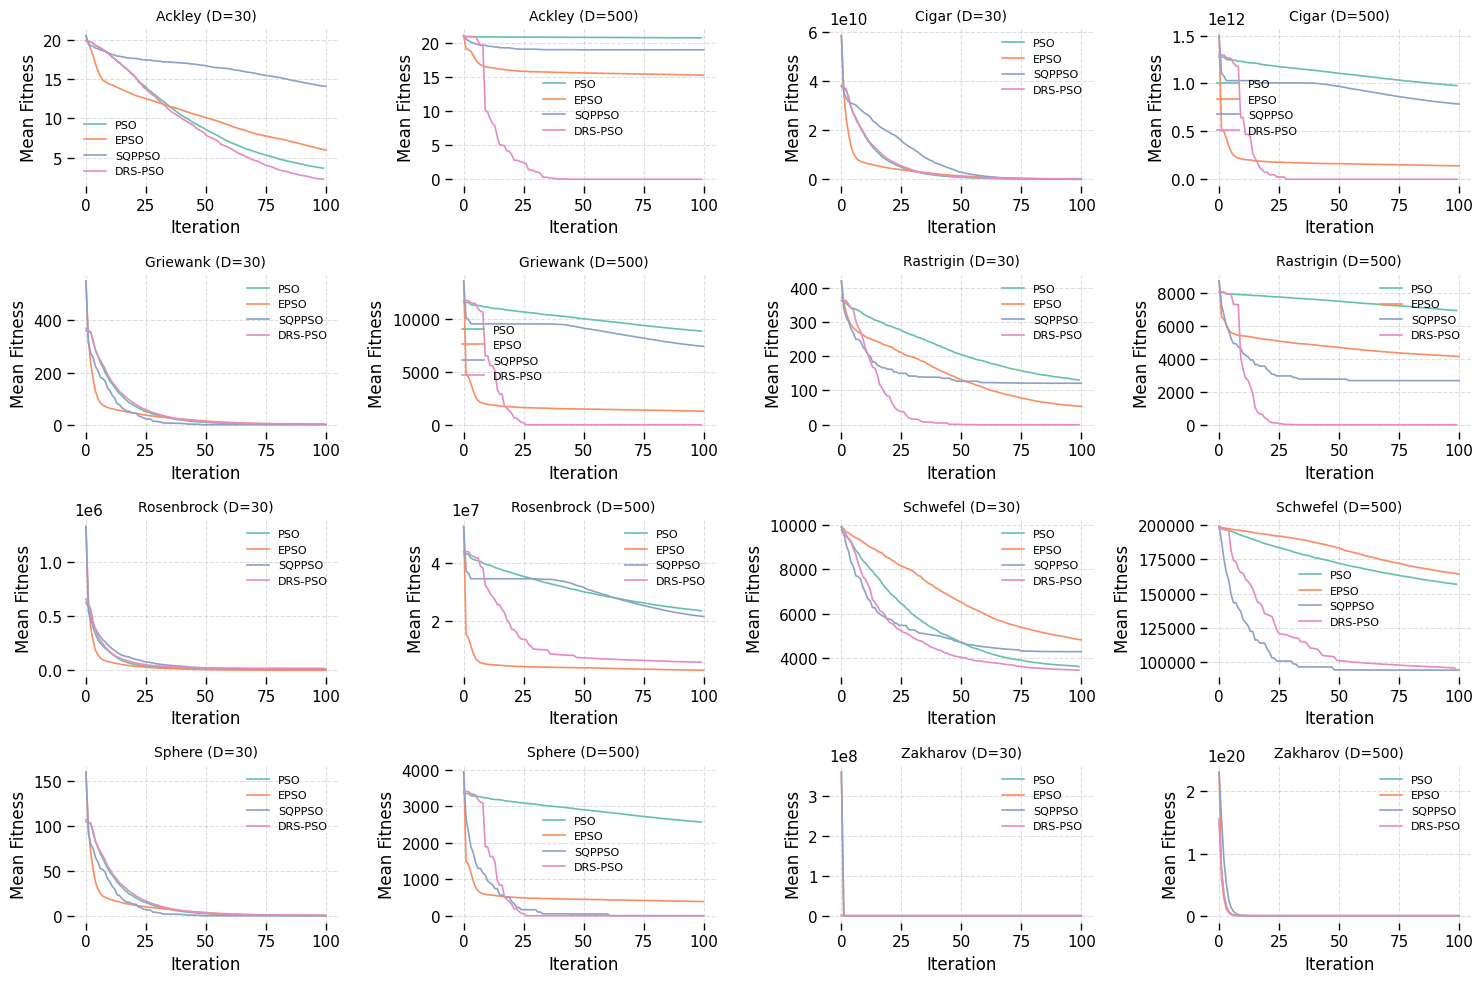

In [6]:
dimensions = [30, 500]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))

benchmarks = df["benchmark"].unique()[:8]

for i, benchmark in enumerate(benchmarks):
    row = i // 2
    col_pair = (i % 2) * 2

    ax_left = axes[row, col_pair]
    subset_30 = df[(df["dimension"] == 30) & (df["benchmark"] == benchmark)]

    for algorithm in subset_30["algorithm"].unique():
        alg_subset = subset_30[subset_30["algorithm"] == algorithm]
        df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
        mean_fitness = df_fitness.mean()
        sns.lineplot(
            x=range(len(mean_fitness)),
            y=mean_fitness,
            label=algorithm,
            ax=ax_left,
        )

    ax_left.set_title(f"{benchmark} (D=30)", fontsize=10)
    ax_left.set_xlabel("Iteration")
    ax_left.set_ylabel("Mean Fitness")
    ax_left.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax_left, left=True, right=True, bottom=True)
    ax_left.grid(linestyle="--", alpha=0.4)

    ax_right = axes[row, col_pair + 1]
    subset_500 = df[(df["dimension"] == 500) & (df["benchmark"] == benchmark)]

    for algorithm in subset_500["algorithm"].unique():
        alg_subset = subset_500[subset_500["algorithm"] == algorithm]
        df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
        mean_fitness = df_fitness.mean()
        std_fitness = df_fitness.std()
        sns.lineplot(
            x=range(len(mean_fitness)),
            y=mean_fitness,
            label=algorithm,
            ax=ax_right,
        )
    ax_right.set_title(f"{benchmark} (D=500)", fontsize=10)
    ax_right.set_xlabel("Iteration")
    ax_right.set_ylabel("Mean Fitness")
    ax_right.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax_right, left=True, right=True, bottom=True)
    ax_right.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../results/convergence_plots.pdf", bbox_inches="tight")
plt.show()

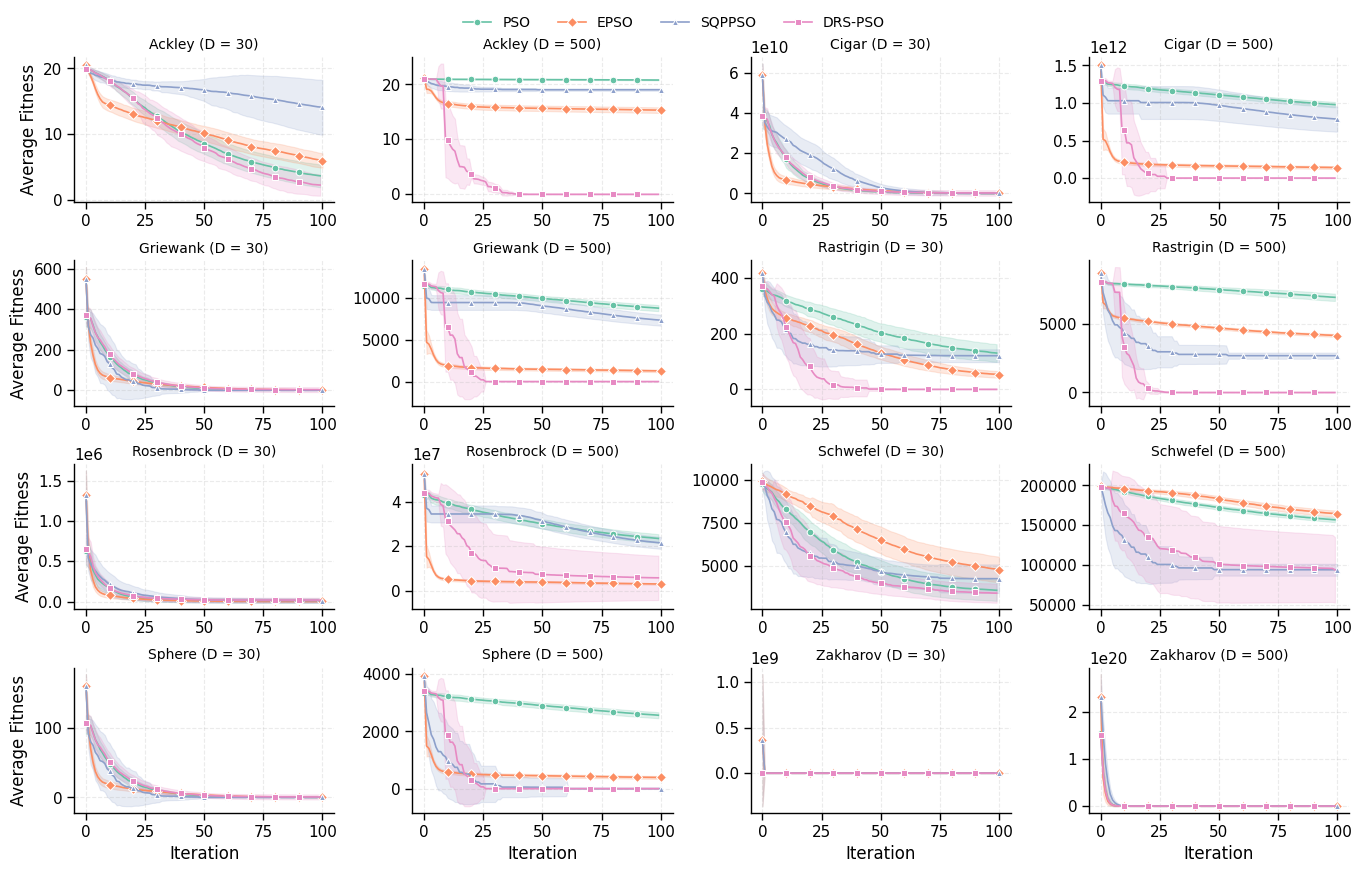

In [7]:
dimensions = [30, 500]
benchmarks = df["benchmark"].unique()[:8]
marker_map = {"PSO": "o", "DRS-PSO": "s", "SQPPSO": "^", "EPSO": "D"}

fig, axes = plt.subplots(4, 4, figsize=(15, 9))

handles, labels = [], []

for i, benchmark in enumerate(benchmarks):
    row = i // 2
    col_pair = (i % 2) * 2

    for j, dim in enumerate(dimensions):
        ax = axes[row, col_pair + j]
        subset = df[(df["dimension"] == dim) & (df["benchmark"] == benchmark)]

        if not subset.empty:
            plot_data = []
            for algorithm in subset["algorithm"].unique():
                alg_subset = subset[subset["algorithm"] == algorithm]
                df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
                df_long = df_fitness.melt(var_name="Iteration", value_name="Fitness")
                df_long["Algorithm"] = algorithm
                plot_data.append(df_long)

            df_plot = pd.concat(plot_data)

            sns.lineplot(
                data=df_plot,
                x="Iteration",
                y="Fitness",
                hue="Algorithm",
                style="Algorithm",
                markers=marker_map,
                dashes=False,
                markevery=10,
                ax=ax,
                errorbar=("sd", 0.95),
                legend=True,
            )

            if not handles:
                handles, labels = ax.get_legend_handles_labels()

            ax.get_legend().remove()

        ax.set_title(f"{benchmark} (D = {dim})", fontsize=10)
        ax.set_xlabel("Iteration" if row == 3 else "")
        ax.set_ylabel("Average Fitness" if col_pair + j == 0 else "")
        ax.grid(visible=True, linestyle="--", alpha=0.25)
        sns.despine(ax=ax)

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, 0.98),
        frameon=False,
        fontsize=10,
    )
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.1, right=0.95, hspace=0.4, wspace=0.3)

plt.savefig("../results/convergence_plots.pdf")
plt.show()

In [8]:
# dimensions = [30, 500]

# fig, axes = plt.subplots(4, 4, figsize=(15, 10))
# axes = axes.flatten()

# for ax, benchmark in zip(axes, df["benchmark"].unique()):
#     subset = df[
#         (df["dimension"] == dimension) & (df["benchmark"] == benchmark)
#     ]

#     for algorithm in subset["algorithm"].unique():
#         alg_subset = subset[subset["al˛gorithm"] == algorithm]
#         df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
#         mean_fitness = df_fitness.mean()
#         sns.lineplot(mean_fitness, label=algorithm, ax=ax)

#     ax.set_title(f"Convergence for {benchmark} (D = {dimension})")
#     ax.set_xlabel("Iteration")
#     ax.set_ylabel("Mean Fitness")
#     ax.legend(frameon=False)
#     sns.despine(ax=ax, left=True, right=True, bottom=True)
#     ax.grid(linestyle="--", alpha=0.4)

# plt.tight_layout()
# plt.savefig("../results/convergence_plots.pdf", bbox_inches="tight")
# plt.show()

In [9]:
algorithm_a = "DRS-PSO"
algorithm_b = "PSO"

threshold = 0.05
df_filtered = df[df["algorithm"].isin([algorithm_a, algorithm_b])]

results = []
for benchmark in df_filtered["benchmark"].unique():
    for dimension in df_filtered["dimension"].unique():
        subset = df_filtered[
            (df_filtered["benchmark"] == benchmark)
            & (df_filtered["dimension"] == dimension)
        ]

        fitness_a = subset[subset["algorithm"] == algorithm_a][
            "best_fitness"
        ].to_numpy()
        fitness_b = subset[subset["algorithm"] == algorithm_b][
            "best_fitness"
        ].to_numpy()

        stat, p_value = stats.wilcoxon(fitness_a, fitness_b, alternative="two-sided")

        median_a = np.median(fitness_a)
        median_b = np.median(fitness_b)

        results.append(
            {
                "benchmark": benchmark,
                "dimension": dimension,
                "median_a": np.median(fitness_a),
                "iqr_a": np.percentile(fitness_a, 75) - np.percentile(fitness_a, 25),
                "median_b": np.median(fitness_b),
                "iqr_b": np.percentile(fitness_b, 75) - np.percentile(fitness_b, 25),
                "p-value": p_value,
                "significance": p_value < threshold,
                "-log10(p-value)": -np.log10(p_value),
                "best_algorithm": algorithm_a
                if np.mean(fitness_a) < np.mean(fitness_b)
                else algorithm_b,
            },
        )

df_results = pd.DataFrame(results)
df_results

,benchmark,dimension,median_a,iqr_a,median_b,iqr_b,p-value,significance,-log10(p-value),best_algorithm
0,Ackley,30,2.971632e+00,3.271559e+00,3.396635e+00,9.784575e-01,1.296514e-05,True,4.887223,DRS-PSO
1,Ackley,100,1.981285e-08,7.000294e-10,1.830370e+01,1.577570e+00,1.776357e-15,True,14.750470,DRS-PSO
2,Ackley,300,1.923851e-08,2.344483e-09,2.060636e+01,1.232916e-01,1.776357e-15,True,14.750470,DRS-PSO
3,Ackley,500,1.971605e-08,8.909922e-10,2.080705e+01,8.235844e-02,1.776357e-15,True,14.750470,DRS-PSO
4,Cigar,30,2.236252e+07,1.883243e+07,2.048161e+07,2.000420e+07,8.707939e-01,False,0.060085,PSO
5,Cigar,100,3.867775e+10,1.519025e+10,4.502230e+10,1.398319e+10,4.094045e-02,True,1.387847,DRS-PSO
6,Cigar,300,7.475008e-09,2.351108e-10,4.608448e+11,2.893458e+10,5.861978e-14,True,13.231956,DRS-PSO
7,Cigar,500,1.247501e-08,1.183037e-11,9.710997e+11,5.127407e+10,1.776357e-15,True,14.750470,DRS-PSO
8,Griewank,30,1.235953e+00,1.888377e-01,1.216153e+00,1.765842e-01,7.304479e-01,False,0.136411,PSO
9,Griewank,100,3.530456e+02,2.771760e+02,3.950354e+02,1.176947e+02,7.082612e-02,False,1.149807,DRS-PSO


In [10]:
latex_table = []
latex_table.append(r"\begin{table*}")
latex_table.append(r"\centering")
latex_table.append(r"\caption{Results}")
latex_table.append(r"\label{tab:results}")

benchmarks = df["benchmark"].unique()
n_cols = len(benchmarks) + 1

latex_table.append(r"\begin{tabular}{l" + "c" * len(benchmarks) + "}")
latex_table.append(r"\toprule")

header = "Algorithm & " + " & ".join(benchmarks) + r" \\"
latex_table.append(header)

algorithm_a = "DRS-PSO"

for dimension in df["dimension"].unique():
    latex_table.append(
        r"\midrule"
        rf"\multicolumn{{9}}{{c}}{{ $D = {dimension}$ }}"
        r"\\ \midrule",
    )
    for algorithm in df["algorithm"].unique():
        row_data = [algorithm]

        for benchmark in benchmarks:
            subset = df[df["algorithm"] == algorithm]
            alg_subset = subset[
                (subset["benchmark"] == benchmark) & (subset["dimension"] == dimension)
            ]["best_fitness"].to_numpy()

            medians = {}

            for algorithm_2 in df["algorithm"].unique():
                subset_2 = df[df["algorithm"] == algorithm_2]
                alg_subset_2 = subset_2[
                    (subset_2["benchmark"] == benchmark)
                    & (subset_2["dimension"] == dimension)
                ]["best_fitness"].to_numpy()
                medians[algorithm_2] = np.median(alg_subset_2)

            print(medians)

            fitness_a = df[
                (df["algorithm"] == algorithm_a)
                & (df["benchmark"] == benchmark)
                & (df["dimension"] == dimension)
            ]["best_fitness"].to_numpy()

            if algorithm != algorithm_a:
                stat, p_value = stats.wilcoxon(
                    fitness_a,
                    alg_subset,
                    alternative="two-sided",
                )

            if len(alg_subset) > 0:
                median = np.median(alg_subset)

                print(medians)

                text = f"{median:.2e}"

                if algorithm != algorithm_a and p_value < threshold:
                    text = f"\\underline{{{text}}}"
                if median == min(medians.values()):
                    row_data.append(f"\\textbf{{{text}}}")
                else:
                    row_data.append(f"{{{text}}}")
            else:
                row_data.append("-")

        latex_table.append(" & ".join(row_data) + r" \\")

latex_table.append(r"\bottomrule")
latex_table.append(r"\end{tabular}")
latex_table.append(r"\end{table*}")

latex_output = "\n".join(latex_table)
print(latex_output)

with Path.open("../results/results_table.tex", "w") as f:
    f.write(latex_output)

{'PSO': np.float64(3.396635221667646), 'EPSO': np.float64(5.801291893240121), 'SQPPSO': np.float64(16.31497195618809), 'DRS-PSO': np.float64(2.9716317637185505)}
{'PSO': np.float64(3.396635221667646), 'EPSO': np.float64(5.801291893240121), 'SQPPSO': np.float64(16.31497195618809), 'DRS-PSO': np.float64(2.9716317637185505)}
{'PSO': np.float64(20481609.233064555), 'EPSO': np.float64(62527538.00485412), 'SQPPSO': np.float64(13988394.423251987), 'DRS-PSO': np.float64(22362517.41263413)}
{'PSO': np.float64(20481609.233064555), 'EPSO': np.float64(62527538.00485412), 'SQPPSO': np.float64(13988394.423251987), 'DRS-PSO': np.float64(22362517.41263413)}
{'PSO': np.float64(1.216153208071135), 'EPSO': np.float64(1.742649048798715), 'SQPPSO': np.float64(1.4196067099625509e-09), 'DRS-PSO': np.float64(1.2359525614873992)}
{'PSO': np.float64(1.216153208071135), 'EPSO': np.float64(1.742649048798715), 'SQPPSO': np.float64(1.4196067099625509e-09), 'DRS-PSO': np.float64(1.2359525614873992)}
{'PSO': np.float

In [11]:
rows = []
for dimension in df["dimension"].unique():
    for algorithm in df["algorithm"].unique():
        row = {}
        row["Algorithm"] = f"{algorithm} ({dimension})"
        for benchmark in df["benchmark"].unique():
            subset = df[df["algorithm"] == algorithm]
            alg_subset = subset[
                (subset["benchmark"] == benchmark) & (subset["dimension"] == dimension)
            ]["best_fitness"].to_numpy()
            median = np.median(alg_subset)
            row[f"{benchmark}"] = f"{median:.4f}"

        rows.append(row)


results_df = pd.DataFrame(rows)
results_df

,Algorithm,Ackley,Cigar,Griewank,Rastrigin,Rosenbrock,Schwefel,Sphere,Zakharov
0,PSO (30),3.3966,20481609.2331,1.2162,125.0412,291.1326,3562.4796,0.0630,259.1758
1,EPSO (30),5.8013,62527538.0049,1.7426,54.5262,463.6384,4884.8156,0.1862,210.7099
2,SQPPSO (30),16.3150,13988394.4233,0.0000,117.5557,142.0975,4484.7693,0.0000,0.0000
3,DRS-PSO (30),2.9716,22362517.4126,1.2360,0.0000,732.5554,3400.5833,0.0687,0.0000
4,PSO (100),18.3037,45022301467.2342,395.0354,903.4255,678297.6266,21435.8167,114.7711,2913.6675
5,EPSO (100),12.5777,8753122895.2148,82.4850,467.4349,96001.2915,23468.3070,25.1706,2540.9571
6,SQPPSO (100),18.4954,32764960913.5209,0.0000,440.7651,500659.1234,18290.9310,0.0000,0.0000
7,DRS-PSO (100),0.0000,38677746682.4999,353.0456,0.0000,697609.0687,12979.9502,102.5407,0.0000
8,PSO (300),20.6064,460844822023.2971,4131.4982,3832.0836,8424615.9742,85537.3863,1203.0948,12671.7430
9,EPSO (300),14.7426,69341923593.5464,607.8137,2190.0091,1318304.1768,90639.7214,187.3668,15329.8163


In [12]:
df_results

,benchmark,dimension,median_a,iqr_a,median_b,iqr_b,p-value,significance,-log10(p-value),best_algorithm
0,Ackley,30,2.971632e+00,3.271559e+00,3.396635e+00,9.784575e-01,1.296514e-05,True,4.887223,DRS-PSO
1,Ackley,100,1.981285e-08,7.000294e-10,1.830370e+01,1.577570e+00,1.776357e-15,True,14.750470,DRS-PSO
2,Ackley,300,1.923851e-08,2.344483e-09,2.060636e+01,1.232916e-01,1.776357e-15,True,14.750470,DRS-PSO
3,Ackley,500,1.971605e-08,8.909922e-10,2.080705e+01,8.235844e-02,1.776357e-15,True,14.750470,DRS-PSO
4,Cigar,30,2.236252e+07,1.883243e+07,2.048161e+07,2.000420e+07,8.707939e-01,False,0.060085,PSO
5,Cigar,100,3.867775e+10,1.519025e+10,4.502230e+10,1.398319e+10,4.094045e-02,True,1.387847,DRS-PSO
6,Cigar,300,7.475008e-09,2.351108e-10,4.608448e+11,2.893458e+10,5.861978e-14,True,13.231956,DRS-PSO
7,Cigar,500,1.247501e-08,1.183037e-11,9.710997e+11,5.127407e+10,1.776357e-15,True,14.750470,DRS-PSO
8,Griewank,30,1.235953e+00,1.888377e-01,1.216153e+00,1.765842e-01,7.304479e-01,False,0.136411,PSO
9,Griewank,100,3.530456e+02,2.771760e+02,3.950354e+02,1.176947e+02,7.082612e-02,False,1.149807,DRS-PSO


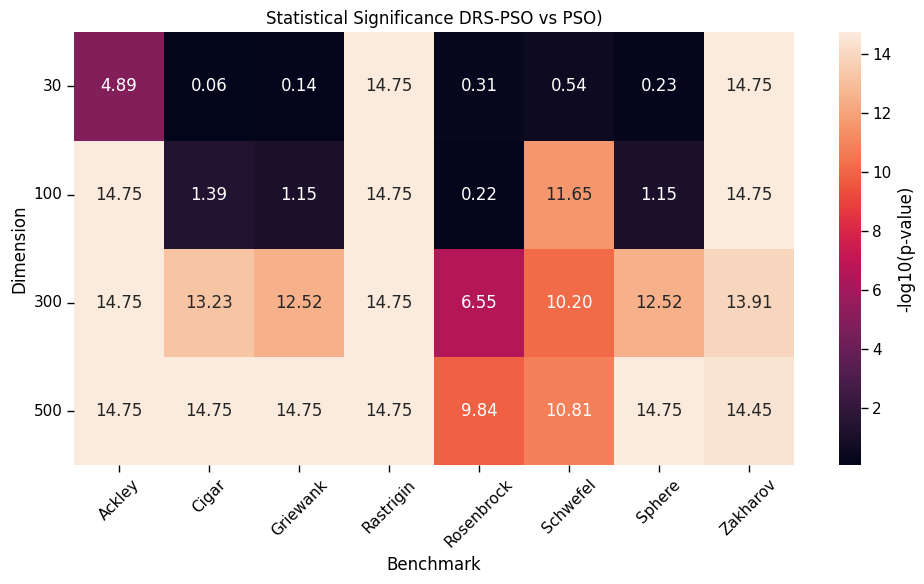

In [13]:
heatmap = df_results.pivot_table("-log10(p-value)", "dimension", "benchmark")
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, annot=True, fmt=".2f", cbar_kws={"label": "-log10(p-value)"})
plt.title("Statistical Significance DRS-PSO vs PSO)")
plt.xlabel("Benchmark")
plt.ylabel("Dimension")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/significance_heatmap.pdf", bbox_inches="tight")
plt.show()

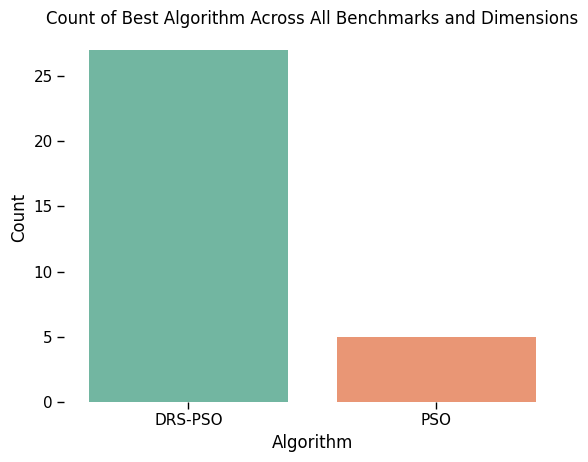

In [14]:
df_count = df_results["best_algorithm"].value_counts().reset_index()
sns.barplot(data=df_count, x="best_algorithm", y="count", hue="best_algorithm")
plt.title("Count of Best Algorithm Across All Benchmarks and Dimensions")
plt.xlabel("Algorithm")
plt.ylabel("Count")
sns.despine(left=True, bottom=True)
plt.savefig("../results/best_algorithm_count.pdf", bbox_inches="tight")
plt.show()

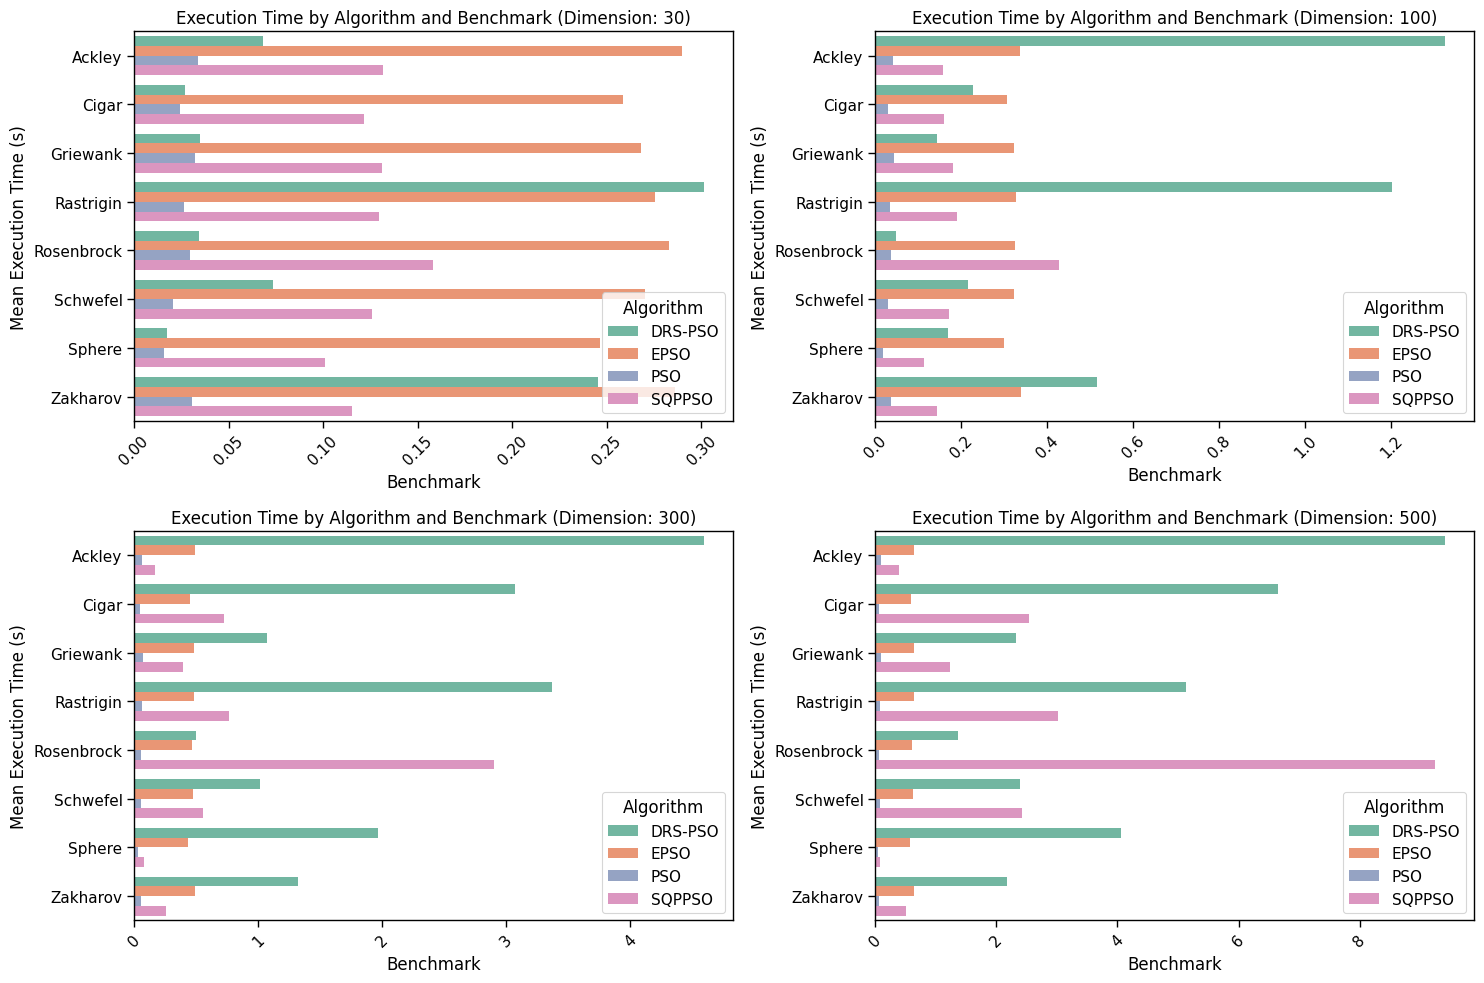

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for ax, dimension in zip(axes, df["dimension"].unique()):
    mean = (
        df[df["dimension"] == dimension]
        .groupby(["benchmark", "algorithm"])["execution_time"]
        .mean()
    )

    sns.barplot(
        x=mean.values,
        y=mean.index.get_level_values("benchmark"),
        hue=mean.index.get_level_values("algorithm"),
        orient="h",
        ax=ax,
    )
    ax.set_title(f"Execution Time by Algorithm and Benchmark (Dimension: {dimension})")
    ax.set_xlabel("Benchmark")
    ax.set_ylabel("Mean Execution Time (s)")
    ax.legend(title="Algorithm")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()